In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
getwd()

[1] "/Users/rob/Projects/R/ISLR2"

In [3]:
source("InstallAndLoadScripts/loadlibraries.R")

In [4]:
loadISLR2Libraries()

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The follow

In [5]:
getwd()

[1] "/Users/rob/Projects/R/ISLR2"

In [6]:
Greenhouses = read.csv("data/Greenhouses.csv")

In [7]:
as_tibble(Greenhouses)[1:10,]

solarPanels,greenhouses,size,price,purpose
<dbl>,<dbl>,<int>,<int>,<chr>
5.0,2.5,430,1500,farm
12.0,3.0,470,2990,general
20.0,2.0,460,2950,power
8.0,3.0,315,1990,farm
7.5,1.5,245,1500,general
12.0,1.5,340,1150,general
16.0,2.0,300,1700,power
16.0,1.5,290,1300,power
12.0,7.5,1035,7500,farm


In [9]:
lm01 = lm(price ~ ., data=Greenhouses)
summary(lm01)


Call:
lm(formula = price ~ ., data = Greenhouses)

Residuals:
    Min      1Q  Median      3Q     Max 
-2170.5  -711.8  -149.1   515.6 12820.6 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -3894.5427   281.9691 -13.812  < 2e-16 ***
solarPanels      153.3251    18.3787   8.343 1.24e-15 ***
greenhouses      618.3029    88.5315   6.984 1.23e-11 ***
size               5.7286     0.4575  12.521  < 2e-16 ***
purposegeneral   445.8654   245.7584   1.814   0.0704 .  
purposepower    -289.8437   384.6625  -0.754   0.4516    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1200 on 394 degrees of freedom
Multiple R-squared:  0.8361,	Adjusted R-squared:  0.834 
F-statistic:   402 on 5 and 394 DF,  p-value: < 2.2e-16


In [10]:
lm02 = lm(price ~ . - purpose, data=Greenhouses)
summary(lm02)


Call:
lm(formula = price ~ . - purpose, data = Greenhouses)

Residuals:
    Min      1Q  Median      3Q     Max 
-2383.6  -723.6  -195.7   551.6 13328.9 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3751.0559   179.9131  -20.85   <2e-16 ***
solarPanels   136.7267    11.2555   12.15   <2e-16 ***
greenhouses   653.5110    48.8598   13.38   <2e-16 ***
size            5.8541     0.4691   12.48   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1233 on 396 degrees of freedom
Multiple R-squared:  0.8261,	Adjusted R-squared:  0.8248 
F-statistic: 627.1 on 3 and 396 DF,  p-value: < 2.2e-16


In [11]:
options(repr.plot.width = 15, repr.plot.height = 12)
f1 = ggplot(Greenhouses, aes(x=greenhouses, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ greenhouses") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

In [12]:
f2 = ggplot(Greenhouses, aes(x=solarPanels, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ solarPanels") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

In [13]:
f3 = ggplot(Greenhouses, aes(x=size, y=price)) +
  geom_point(size=0.75, col="orange") +
  geom_smooth(method = "lm", col="blue") +
  ggtitle("price ~ size") +
  #xlim(0, 300) +
  scale_fill_hue(l=40)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


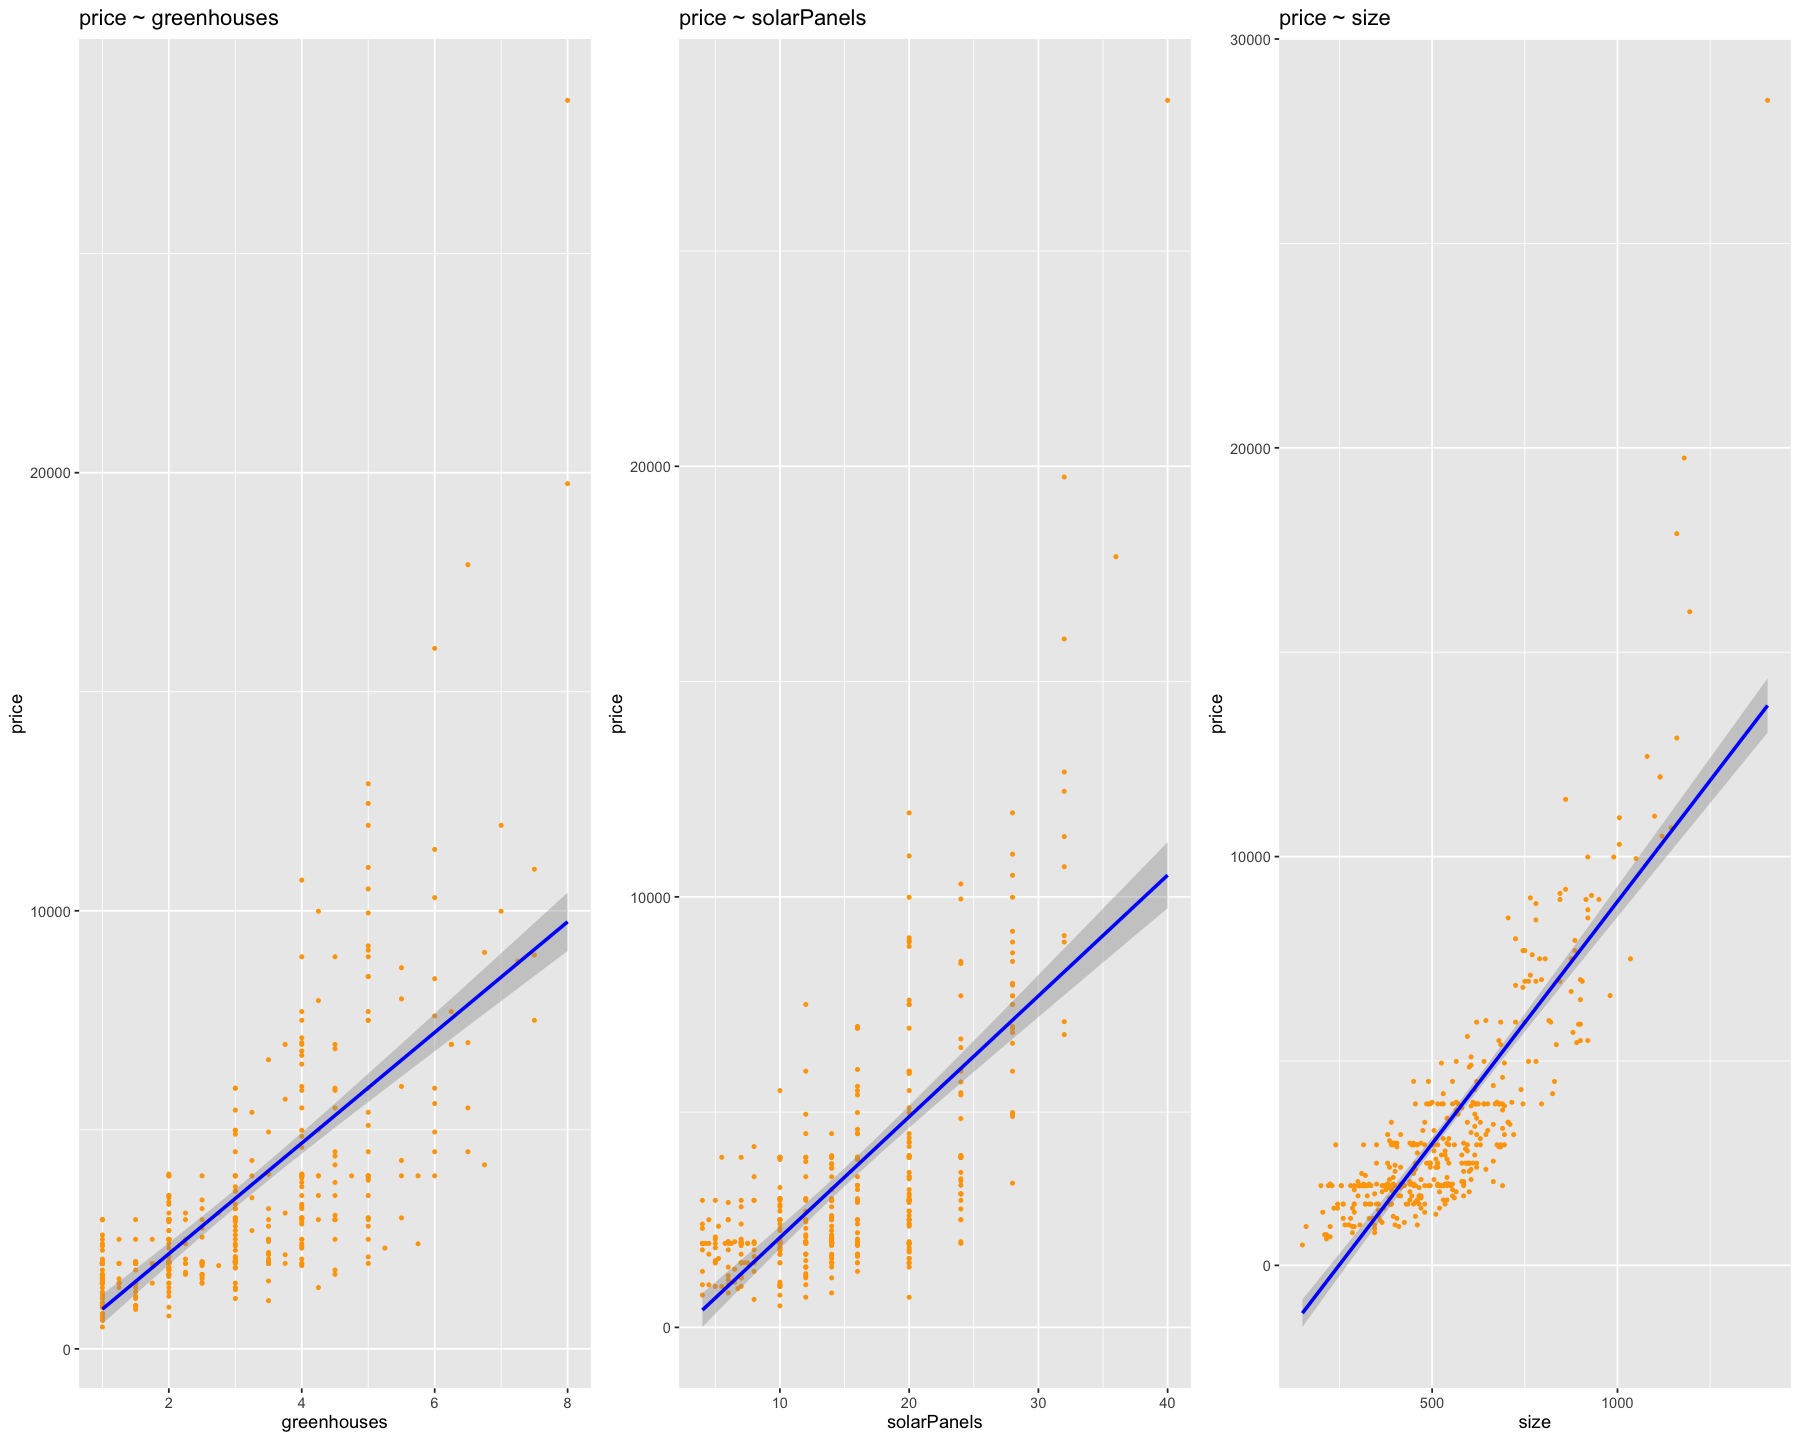

In [14]:
grid.arrange(f1, f2, f3, ncol = 3)

In [15]:
names(lm01)

[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "contrasts"     "xlevels"       "call"          "terms"        
[13] "model"

In [16]:
residuals(lm02)[1:10]

1           2           3           4           5           6 
  416.39074   388.38501   -33.37698   842.67415  1811.08957   289.68180 
          7           8           9          10 
  200.18257   185.47886 -1349.96922  -157.33460

In [17]:
RSS = sum(residuals(lm02)^2)

In [18]:
RSS

[1] 601684700

In [19]:
MSE = sqrt(RSS/396)

In [20]:
MSE

[1] 1232.642

In [21]:
mean_price = mean(Greenhouses$price)

In [22]:
mean_price

[1] 3527.775

In [23]:
TSS = sum((Greenhouses$price - mean_price)^2)

In [24]:
TSS

[1] 3460029320

In [25]:
R2 = 1 - RSS/TSS

In [26]:
R2

[1] 0.8261042

In [27]:
cor(Greenhouses$price, predict(lm02))^2

[1] 0.8261042

In [28]:
p = 3

In [29]:
n = 396

In [30]:
R_adj = 1 - ((1 - R2) * (n - 1) / (n - p - 1))

In [31]:
R_adj

[1] 0.8247733

In [32]:
F_stat = ((TSS-RSS)/p)/(RSS/(n-p-1))

In [33]:
F_stat

[1] 620.741

In [34]:
p_value = pf(F_stat, p, n-p-1, lower.tail=FALSE)

In [35]:
p_value

[1] 1.798221e-148

In [36]:
str_interp("RSS = ${RSS}, MSE = ${MSE}, R2 = ${R2}, R_adj = ${R_adj}, F = ${F_stat}, 
           p = ${p_value}")

[1] "RSS = 601684700.478408, MSE = 1232.64180088496, R2 = 0.826104161301764, R_adj = 0.824773325801523, F = 620.741001537601, \n           p = 1.79822073379053e-148"

In [37]:
summary(lm02)


Call:
lm(formula = price ~ . - purpose, data = Greenhouses)

Residuals:
    Min      1Q  Median      3Q     Max 
-2383.6  -723.6  -195.7   551.6 13328.9 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3751.0559   179.9131  -20.85   <2e-16 ***
solarPanels   136.7267    11.2555   12.15   <2e-16 ***
greenhouses   653.5110    48.8598   13.38   <2e-16 ***
size            5.8541     0.4691   12.48   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1233 on 396 degrees of freedom
Multiple R-squared:  0.8261,	Adjusted R-squared:  0.8248 
F-statistic: 627.1 on 3 and 396 DF,  p-value: < 2.2e-16


In [38]:
Greenhouses$pred = predict(lm02)

In [39]:
as_tibble(Greenhouses)[1:10,]

solarPanels,greenhouses,size,price,purpose,pred
<dbl>,<dbl>,<int>,<int>,<chr>,<dbl>
5.0,2.5,430,1500,farm,1083.6093
12.0,3.0,470,2990,general,2601.6150
20.0,2.0,460,2950,power,2983.3770
8.0,3.0,315,1990,farm,1147.3258
7.5,1.5,245,1500,general,-311.0896
12.0,1.5,340,1150,general,860.3182
16.0,2.0,300,1700,power,1499.8174
16.0,1.5,290,1300,power,1114.5211
12.0,7.5,1035,7500,farm,8849.9692


In [41]:
dim(Greenhouses)

[1] 400   6

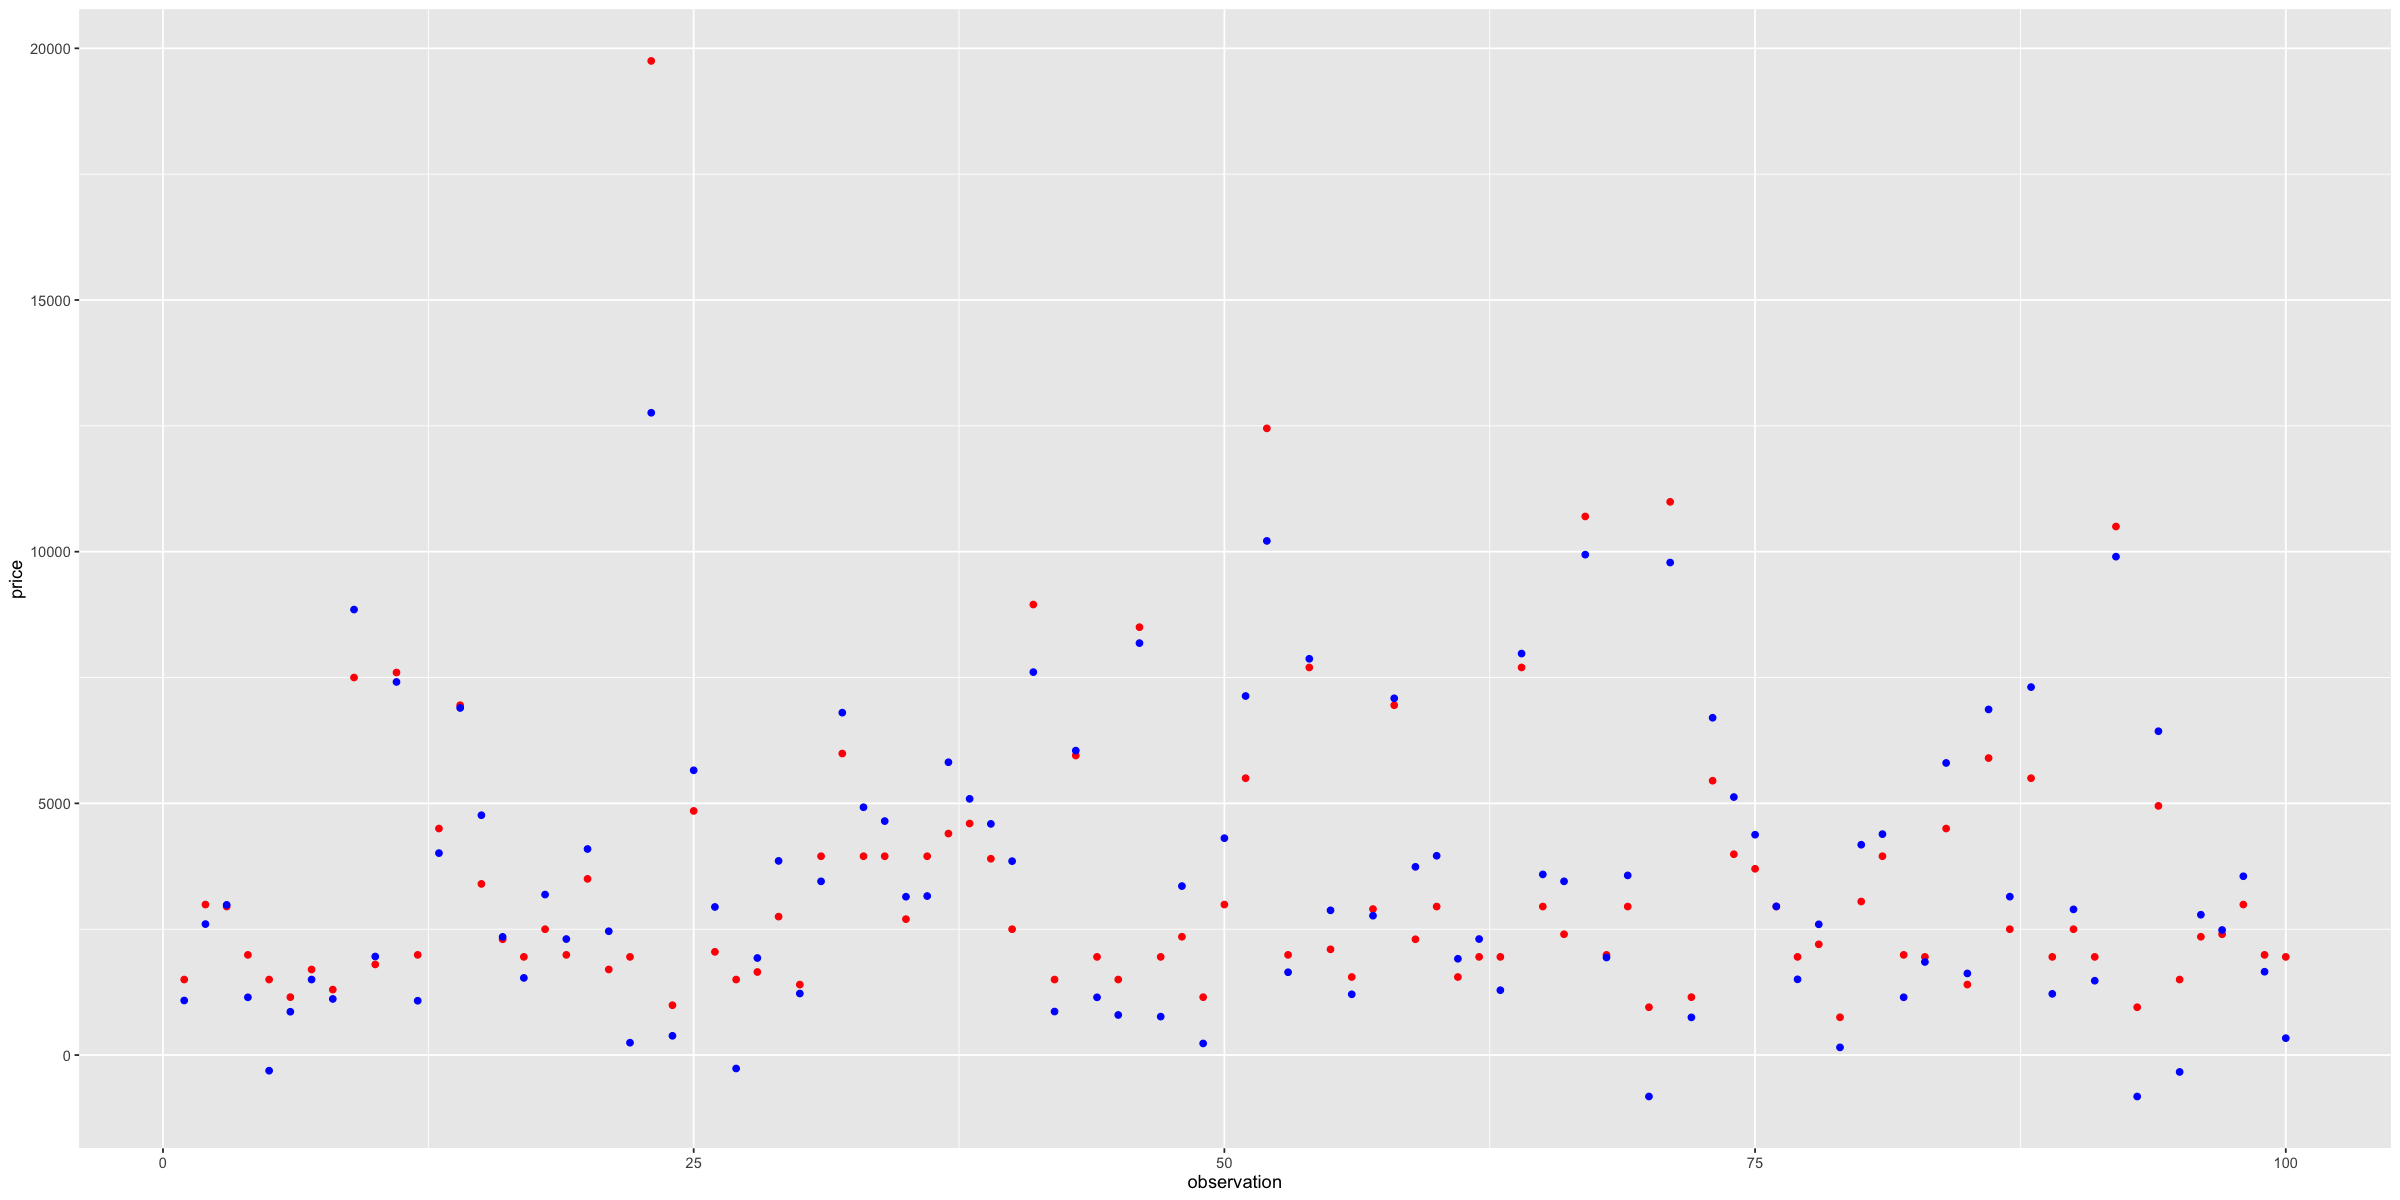

In [42]:
options(repr.plot.width = 20, repr.plot.height =10)
ggplot() + 
  geom_point(data = Greenhouses[1:100,], aes(x=1:100, y = price), color = "red") +
  geom_point(data = Greenhouses[1:100,], aes(x=1:100, y = pred), color = "blue") +
  xlab('observation') + ylab('price')

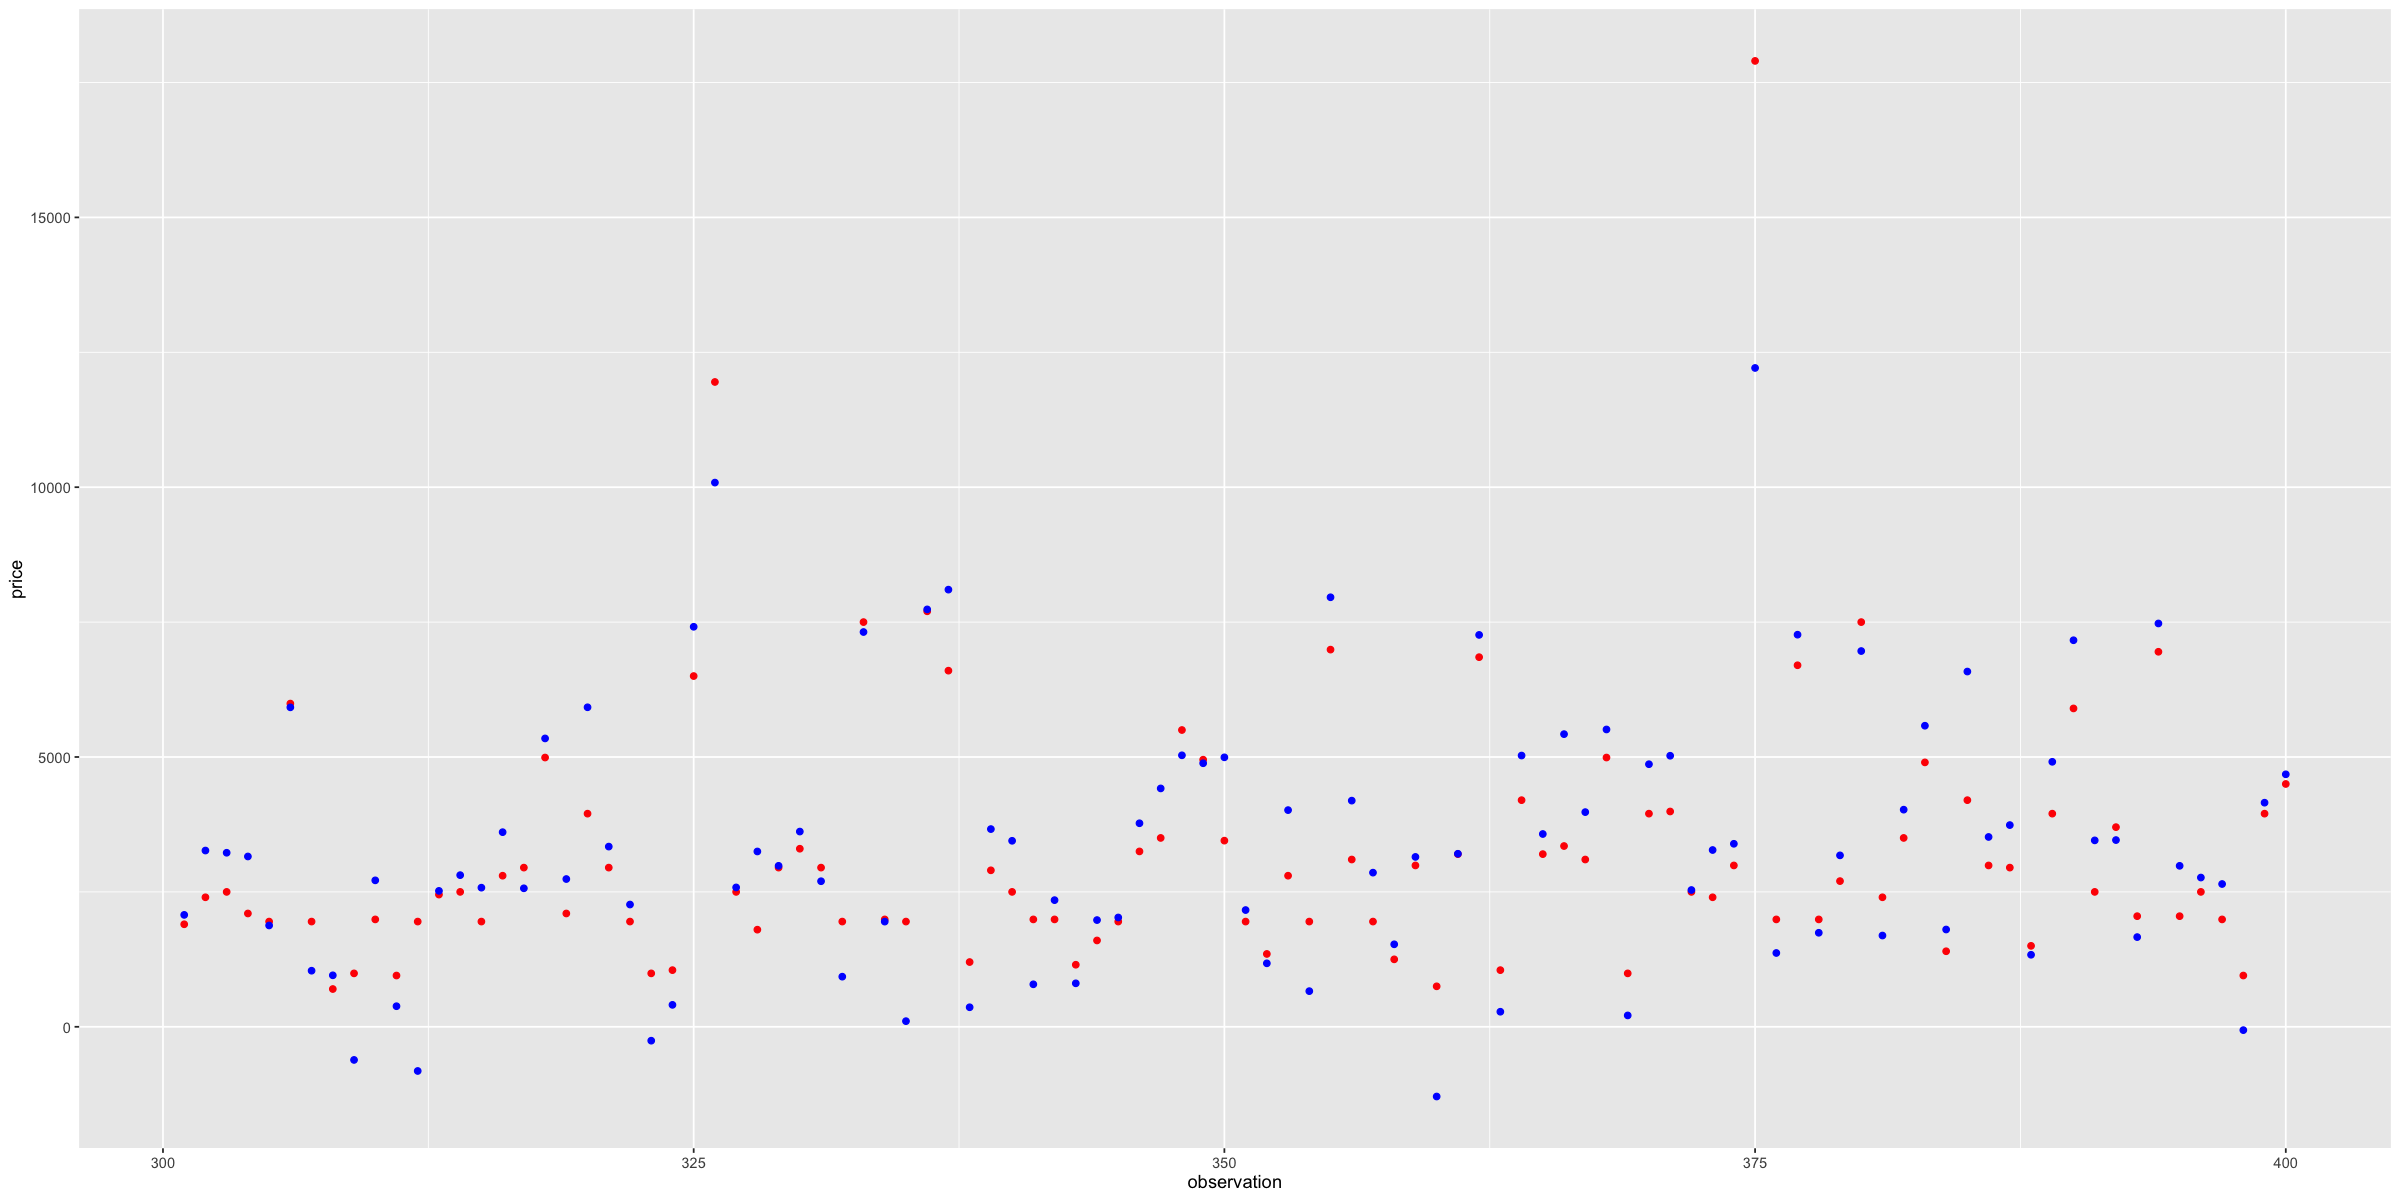

In [43]:
options(repr.plot.width = 20, repr.plot.height =10)
ggplot() + 
  geom_point(data = Greenhouses[301:400,], aes(x=301:400, y = price), color = "red") +
  geom_point(data = Greenhouses[301:400,], aes(x=301:400, y = pred), color = "blue") +
  xlab('observation') + ylab('price')

In [44]:
Greenhouses[c(2,5,6,29,30,33,39,41,42,46,53,70,72) + 1,]

,solarPanels,greenhouses,size,price,purpose,pred
,<dbl>,<dbl>,<int>,<int>,<chr>,<dbl>
3,20,2.00,460,2950,power,2983.3770
6,12,1.50,340,1150,general,860.3182
7,16,2.00,300,1700,power,1499.8174
30,6,4.25,235,1400,farm,1222.4348
31,14,2.00,680,3950,general,3450.9140
34,12,4.25,680,3950,farm,4647.8604
40,24,2.00,515,2500,power,3852.2582
42,7,3.00,290,1500,farm,864.2471
43,28,3.00,685,5950,power,6047.8696
